In [48]:
import numpy as np
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
conn = sqlite3.connect("/Users/laksh/OneDrive/Documents/Projects/Supervised Learning/Vendor_Invoice_Intelligence/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [50]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [51]:
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select *from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [52]:
vendor_df = pd.read_sql_query("select *from vendor_invoice",conn)

In [53]:
df_vendorname = pd.read_sql_query("SELECT VendorName, Freight FROM vendor_invoice",conn)

In [54]:

df_encoded = pd.get_dummies(df_vendorname, columns=['VendorName'], dtype=int)

# 3. Calculate correlation safely (ignoring any leftover string text columns)
# Adding numeric_only=True completely avoids the "could not convert string to float" crash!
correlation_matrix = df_encoded.corr(numeric_only=True)

# 4. Extract how each vendor correlates explicitly with Freight
vendor_freight_corr = correlation_matrix['Freight'].sort_values(ascending=False)

print("--- 🚚 Vendor Correlation with Freight ---")
# Drop Freight's correlation with itself (1.0) to see only the actual suppliers
print(vendor_freight_corr.drop('Freight'))

--- 🚚 Vendor Correlation with Freight ---
VendorName_DIAGEO NORTH AMERICA INC       0.614157
VendorName_MARTIGNETTI COMPANIES          0.327653
VendorName_JIM BEAM BRANDS COMPANY        0.274493
VendorName_PERNOD RICARD USA              0.274236
VendorName_BACARDI USA INC                0.186243
                                            ...   
VendorName_ATLANTIC IMPORTING COMPANY    -0.040204
VendorName_ZORVINO VINEYARDS             -0.040379
VendorName_JEWELL TOWNE VINEYARDS        -0.040410
VendorName_SURVILLE ENTERPRISES CORP     -0.040463
VendorName_TAKARA SAKE USA INC           -0.040929
Name: Freight, Length: 129, dtype: float64


In [55]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [56]:
vendor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


In [57]:
vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


In [58]:
vendor_df.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

<Axes: >

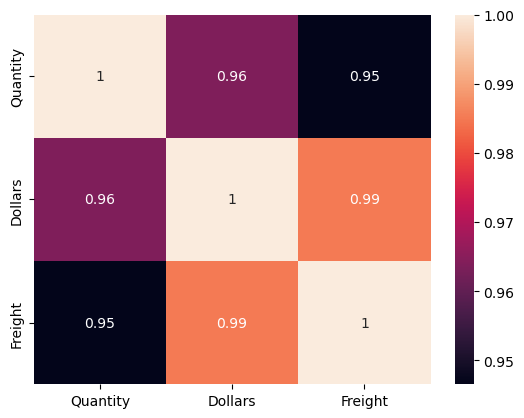

In [59]:
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot = True)

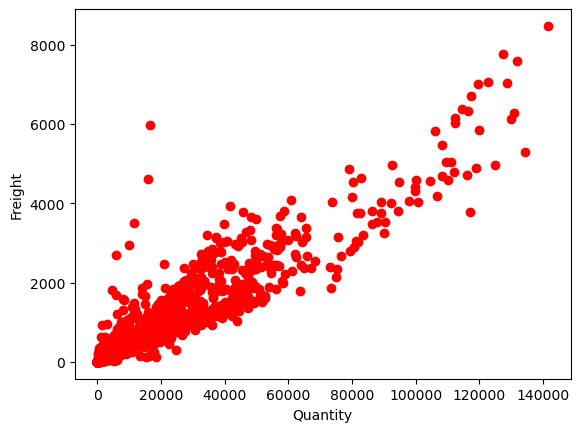

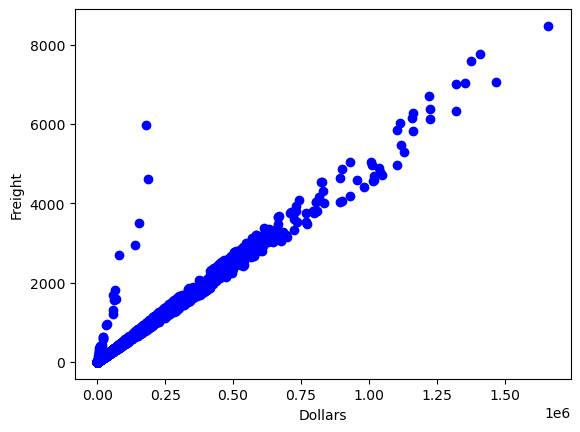

In [60]:
plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color = 'red')
plt.xlabel('Quantity')
plt.ylabel('Freight')
plt.show()

plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color = 'blue')
plt.xlabel('Dollars')
plt.ylabel('Freight')
plt.show()

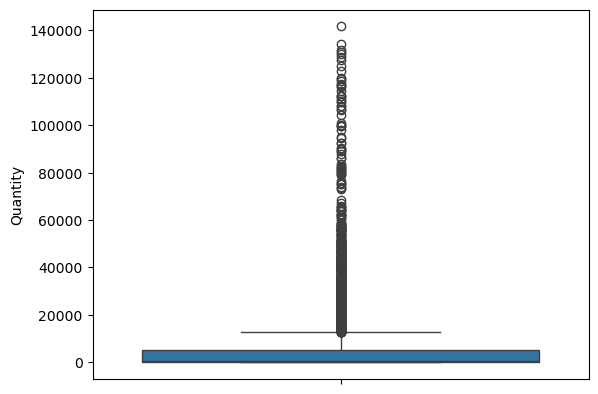

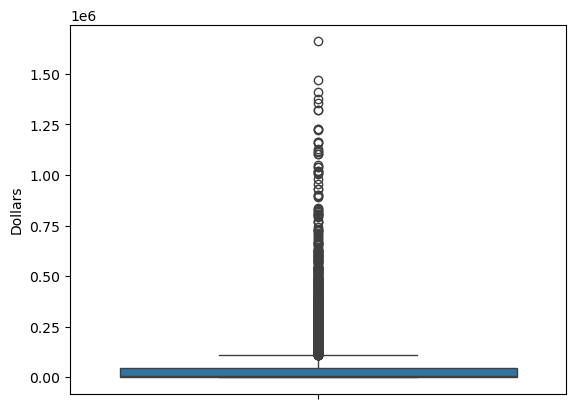

In [61]:
sns.boxplot(vendor_df['Quantity'])
plt.show()
sns.boxplot(vendor_df['Dollars'])
plt.show()

In [62]:
vendor_df['Quantity'].skew()

np.float64(4.4598553975554065)

In [63]:
vendor_df['Dollars'].skew()

np.float64(4.624127407728971)

In [64]:
X = vendor_df[['Quantity','Dollars']]
y = vendor_df['Freight']

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 42, test_size=0.2)

In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
model = LinearRegression()

In [69]:
model.fit(X_train,y_train)

LinearRegression()

In [70]:
y_pred = model.predict(X_test)

In [72]:
from sklearn.metrics import r2_score,mean_absolute_error

In [73]:
print('r2_score:',r2_score(y_test,y_pred)* 100)
print('MAE',mean_absolute_error(y_test,y_pred))

r2_score: 97.00197330175597
MAE 24.45918076526339


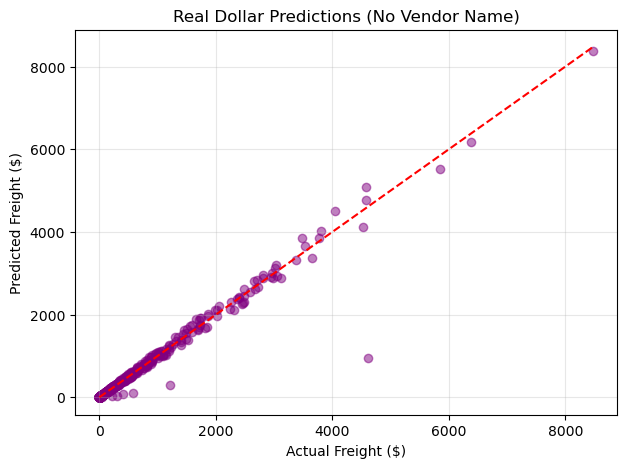

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='purple', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Real Dollar Predictions (No Vendor Name)')
plt.xlabel('Actual Freight ($)')
plt.ylabel('Predicted Freight ($)')
plt.grid(True, alpha=0.3)
plt.show()